# NetworkX basics tutorial
Adapted from: https://networkx.org/documentation/stable/tutorial.html

This guide can help you start working with NetworkX.



## Some background knowledge: dictionary data structure

In NetworkX, the links of the network is stored in 'dictionary' data structure. Dictionary data contains key:value pairs, for easy look up of values

In [1]:
# Define a dictionary and add a new key-value pair
tel = {'jack': 4098, 'jenny': 4139}
tel['john'] = 4127
tel

{'jack': 4098, 'jenny': 4139, 'john': 4127}

In [2]:
# Get the keys of the dictionary
tel.keys()

dict_keys(['jack', 'jenny', 'john'])

In [3]:
# Alternative way to get the 'keys' of the dictionary
list(tel)

['jack', 'jenny', 'john']

In [4]:
# Get a sorted list of the keys
sorted(tel)

['jack', 'jenny', 'john']

In [5]:
# Get the values of the dictionary
tel.values()

dict_values([4098, 4139, 4127])

In [6]:
# Get the number of key-value pairs in the dictionary
len(tel)

3

In [7]:
# Get the value of a specific key
tel['jack']

4098

# NetworkX tutorial

### Creating a graph

Create an empty graph with no nodes and no edges.

In [8]:
import networkx as nx
G = nx.Graph()

By definition, a `Graph` is a collection of nodes (vertices) along with
identified pairs of nodes (called edges, links, etc).  In NetworkX, nodes can
be any [hashable](https://docs.python.org/3/glossary.html#term-hashable) object e.g., a text string, an image, an XML object,
another Graph, a customized node object, etc.

# Nodes

The graph `G` can be grown in several ways.  NetworkX includes many
graph generator functions and
facilities to read and write graphs in many formats.
To get started though we’ll look at simple manipulations.  You can add one node
at a time,

In [9]:
G.add_node(1)

or add nodes from any [iterable](https://docs.python.org/3/glossary.html#term-iterable) container, such as a list

In [10]:
G.add_nodes_from([2, 3])

You can also add nodes along with node
attributes if your container yields 2-tuples of the form
`(node, node_attribute_dict)`:

In [11]:
G.add_nodes_from([
    (4,{"color":"red"}),
    (5,{"color":"green"}),
])

# Edges

`G` can also be grown by adding one edge at a time,

In [12]:
G.add_edge(1, 2)
e = (2, 3)
G.add_edge(*e)  # unpack edge tuple*

by adding a list of edges,

In [13]:
G.add_edges_from([(1, 2), (1, 3)])

There are no complaints when adding existing nodes or edges. For example,
after removing all nodes and edges,

In [14]:
G.clear()

we add new nodes/edges and NetworkX quietly ignores any that are
already present.

In [15]:
G.add_edges_from([(1, 2), (1, 3)])
G.add_node(1)
G.add_edge(1, 2)
G.add_node("spam")        # adds node "spam"
G.add_nodes_from("spam")  # adds 4 nodes: 's', 'p', 'a', 'm'
G.add_edge(3, 'm')

At this stage the graph `G` consists of 8 nodes and 3 edges, as can be seen by:

In [16]:
# Get the number of nodes
G.number_of_nodes()

8

In [17]:
# Get the number of edges
G.number_of_edges()

3

# Examining elements of a graph

We can examine the nodes and edges. Four basic graph properties facilitate
reporting: `G.nodes`, `G.edges`, `G.adj` and `G.degree`.  These
are set-like views of the nodes, edges, neighbors (adjacencies), and degrees
of nodes in a graph. They offer a continually updated read-only view into
the graph structure. They are also dict-like in that you can look up node
and edge data attributes via the views and iterate with data attributes
using methods `.items()`, `.data()`.
If you want a specific container type instead of a view, you can specify one.
Here we use lists, though sets, dicts, tuples and other containers may be
better in other contexts.

In [18]:
list(G.nodes)

[1, 2, 3, 'spam', 's', 'p', 'a', 'm']

In [19]:
list(G.edges)

[(1, 2), (1, 3), (3, 'm')]

In [20]:
list(G.adj[1])  # or list(G.neighbors(1))

[2, 3]

In [21]:
G.degree[1]  # the degree of node 1

2

# Removing elements from a graph

One can remove nodes and edges from the graph in a similar fashion to adding.
Use methods
`Graph.remove_node()`,
`Graph.remove_nodes_from()`,
`Graph.remove_edge()`
and
`Graph.remove_edges_from()`, e.g.

In [22]:
G.remove_node(2)
G.remove_nodes_from("spam")
list(G.nodes)

[1, 3, 'spam']

In [23]:
G.remove_edge(1, 3)

# Using the graph constructors

Graph objects do not have to be built up incrementally - data specifying
graph structure can be passed directly to the constructors of the various
graph classes.
When creating a graph structure by instantiating one of the graph
classes you can specify data in several formats.

In [24]:
# Create a directed graph from an undirected graph
G.add_edge(1, 2)
H = nx.DiGraph(G)  # create a DiGraph using the connections from G
list(H.edges())

[(1, 2), (2, 1)]

In [25]:
# Create a graph from an edge list
edgelist = [(0, 1), (1, 2), (2, 3)]
H = nx.Graph(edgelist)  # create a graph from an edge list
list(H.edges())

[(0, 1), (1, 2), (2, 3)]

In [26]:
# Create a graph from an adjacency dictionary
adjacency_dict = {0: (1, 2), 1: (0, 2), 2: (0, 1)}
H = nx.Graph(adjacency_dict)  # create a Graph dict mapping nodes to nbrs
list(H.edges())

[(0, 1), (0, 2), (1, 2)]

In [27]:
# View the adjacency dictionary
H.adj

AdjacencyView({0: {1: {}, 2: {}}, 1: {0: {}, 2: {}}, 2: {0: {}, 1: {}}})

# Accessing edges and neighbors

In addition to the views `Graph.edges`, and `Graph.adj`,
access to edges and neighbors is possible using subscript notation.

In [28]:
G = nx.Graph([(1, 2, {"color": "yellow"})])
G[1]  # same as G.adj[1]

AtlasView({2: {'color': 'yellow'}})

In [29]:
# Get the edge attribute dictionary
G[1][2]

{'color': 'yellow'}

In [30]:
# Another way to get the edge attribute dictionary
G.edges[1, 2]

{'color': 'yellow'}

You can get/set the attributes of an edge using subscript notation
if the edge already exists.

In [31]:
G.add_edge(1, 3)
G[1][3]['color'] = "blue"
G.edges[1, 2]['color'] = "red"
G.edges[1, 2]

{'color': 'red'}

In [32]:
G.edges[1,3]

{'color': 'blue'}

Fast examination of all (node, adjacency) pairs is achieved using
`G.adjacency()`, or `G.adj.items()`.
Note that for undirected graphs, adjacency iteration sees each edge twice.

In [33]:
FG = nx.Graph()
FG.add_weighted_edges_from([(1, 2, 0.125), (1, 3, 0.75), (2, 4, 1.2), (3, 4, 0.375)])
for n, nbrs in FG.adj.items():
   for nbr, eattr in nbrs.items():
       wt = eattr['weight']
       if wt < 0.5: print(f"({n}, {nbr}, {wt:.3})")

(1, 2, 0.125)
(2, 1, 0.125)
(3, 4, 0.375)
(4, 3, 0.375)


Convenient access to all edges is achieved with the edges property.

In [34]:
for (u, v, wt) in FG.edges.data('weight'):
    if wt < 0.5:
        print(f"({u}, {v}, {wt:.3})")

(1, 2, 0.125)
(3, 4, 0.375)


# Adding attributes to graphs, nodes, and edges

Attributes such as weights, labels, colors, or whatever Python object you like,
can be attached to graphs, nodes, or edges.

Each graph, node, and edge can hold key/value attribute pairs in an associated
attribute dictionary (the keys must be hashable).  By default these are empty,
but attributes can be added or changed using `add_edge`, `add_node` or direct
manipulation of the attribute dictionaries named `G.graph`, `G.nodes`, and
`G.edges` for a graph `G`.

## Graph attributes

Assign graph attributes when creating a new graph

In [35]:
G = nx.Graph(day="Friday")
G.graph

{'day': 'Friday'}

Or you can modify attributes later

In [36]:
G.graph['day'] = "Monday"
G.graph

{'day': 'Monday'}

# Node attributes

Add node attributes using `add_node()`, `add_nodes_from()`, or `G.nodes`

In [37]:
G.add_node(1, time='5pm')
G.add_nodes_from([3], time='2pm')
G.nodes[1]

{'time': '5pm'}

In [38]:
G.nodes[1]['room'] = 714
G.nodes.data()

NodeDataView({1: {'time': '5pm', 'room': 714}, 3: {'time': '2pm'}})

Note that adding a node to `G.nodes` does not add it to the graph, use
`G.add_node()` to add new nodes. Similarly for edges.

# Edge Attributes

Add/change edge attributes using `add_edge()`, `add_edges_from()`,
or subscript notation.

In [39]:
G.add_edge(1, 2, weight=4.7 )
G.add_edges_from([(3, 4), (4, 5)], color='red')
G.add_edges_from([(1, 2, {'color': 'blue'}), (2, 3, {'weight': 8})])
G[1][2]['weight'] = 4.7
G.edges[3, 4]['weight'] = 4.2

The special attribute `weight` should be numeric as it is used by algorithms requiring weighted edges.

 # Directed graphs

The `DiGraph` class provides additional methods and properties specific
to directed edges, e.g.,
`DiGraph.out_edges`, `DiGraph.in_degree`,
`DiGraph.predecessors`, `DiGraph.successors` etc.
To allow algorithms to work with both classes easily, the directed versions of
`neighbors` is equivalent to
`successors` while `degree` reports the sum
of `in_degree` and `out_degree` even though that may feel inconsistent at times.

In [40]:
DG = nx.DiGraph()
DG.add_weighted_edges_from([(1, 2, 0.5), (3, 1, 0.75)])
DG.out_degree(1, weight='weight')

0.5

In [41]:
DG.out_degree(1)

1

In [42]:
DG.degree(1, weight='weight')

1.25

In [43]:
DG.degree(1)

2

In [44]:
list(DG.successors(1))

[2]

In [45]:
list(DG.neighbors(1))

[2]

In [46]:
list(DG.predecessors(1))

[3]

Some algorithms work only for directed graphs and others are not well
defined for directed graphs.  Indeed the tendency to lump directed
and undirected graphs together is dangerous.  If you want to treat
a directed graph as undirected for some measurement you should probably
convert it using `Graph.to_undirected()` or with

In [47]:
H = nx.Graph(G)  # create an undirected graph H from a directed graph G

# Graph generators and graph operations

In addition to constructing graphs node-by-node or edge-by-edge, they
can also be generated by

### 1. Using a (constructive) generator for a classic graph,

In [48]:
K_5 = nx.complete_graph(5)
K_3_5 = nx.complete_bipartite_graph(3, 5)
barbell = nx.barbell_graph(10, 10)
lollipop = nx.lollipop_graph(10, 20)

### 2. Using a stochastic graph generator, e.g,

like:

In [49]:
er = nx.erdos_renyi_graph(100, 0.15)
ws = nx.watts_strogatz_graph(30, 3, 0.1)
ba = nx.barabasi_albert_graph(100, 5)
red = nx.random_lobster(100, 0.9, 0.9)

### 5. Using a stochastic graph generator

In [50]:
er = nx.erdos_renyi_graph(100, 0.15)

In [51]:
ba = nx.barabasi_albert_graph(100, 5)

# Analyzing graphs

The structure of `G` can be analyzed using various graph-theoretic
functions such as:

In [52]:
G = nx.Graph()
G.add_edges_from([(1, 2), (1, 3)])
G.add_node("spam")       # adds node "spam"
list(nx.connected_components(G))

[{1, 2, 3}, {'spam'}]

In [53]:
sorted(d for n, d in G.degree())

[0, 1, 1, 2]

See Algorithms for details on graph algorithms supported.
https://networkx.org/documentation/stable/reference/algorithms/index.html


# Drawing graphs

NetworkX is not primarily a graph drawing package but basic drawing with
Matplotlib as well as an interface to use the open source Graphviz software
package are included.  These are part of the networkx.drawing
module and will be imported if possible.

First import Matplotlib’s plot interface (pylab works too)

In [54]:
import matplotlib.pyplot as plt

To test if the import of `nx_pylab` was successful draw `G`
using one of

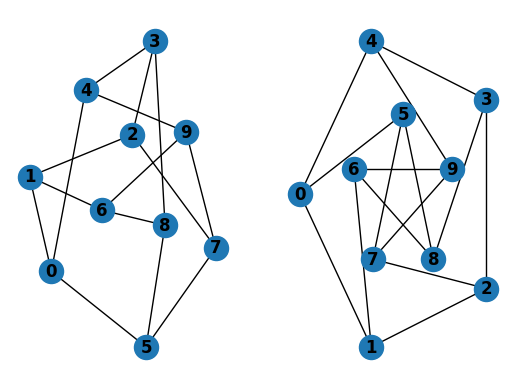

In [55]:
G = nx.petersen_graph()
subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold')
subax2 = plt.subplot(122)
nx.draw_shell(G, nlist=[range(5, 10), range(5)], with_labels=True, font_weight='bold')

Another example of different style of drawing the network

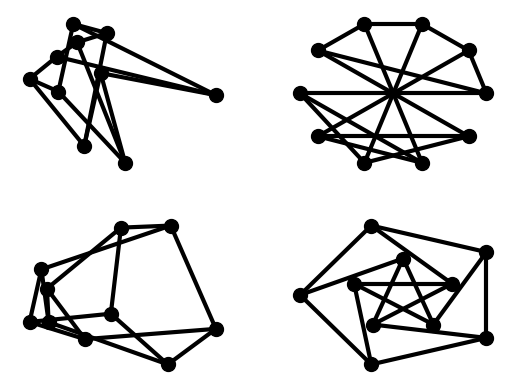

In [56]:
options = {
    'node_color': 'black',
    'node_size': 100,
    'width': 3,
}
subax1 = plt.subplot(221)
nx.draw_random(G, **options)
subax2 = plt.subplot(222)
nx.draw_circular(G, **options)
subax3 = plt.subplot(223)
nx.draw_spectral(G, **options)
subax4 = plt.subplot(224)
nx.draw_shell(G, nlist=[range(5,10), range(5)], **options)

To save drawings to a file, use, for example

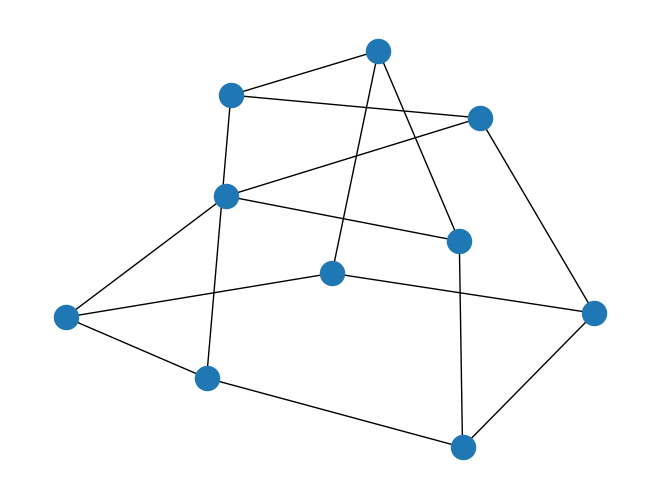

In [57]:
nx.draw(G)
plt.savefig("path.png")

## Free network visualization tool
Gephi, https://gephi.org/

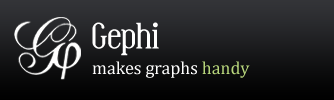

### Singapore Twitter/X network

![Singapore twitter network.jpg](<attachment:Singapore twitter network.jpg>)